In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("cleaned_data/tbills.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

In [4]:
df.shape

(3053, 1)

In [5]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3053 entries, 2015-01-01 to 2026-04-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   3053 non-null   float64
dtypes: float64(1)
memory usage: 47.7 KB


In [6]:
df.head()

,price
date,
2015-01-01,11.95
2015-01-02,11.95
2015-01-04,12.20
2015-01-05,11.95
2015-01-06,12.20


In [7]:
df.tail()

,price
date,
2026-04-24,23.285
2026-04-27,23.257
2026-04-28,23.765
2026-04-29,23.642
2026-04-30,23.671


In [8]:
#print null count
print(df.isnull().sum())

price    0
dtype: int64


In [9]:
# 1. Calculate Daily Return (This is your daily Rf)
df['daily_return'] = df['price'].pct_change()

In [10]:
# We shift the returns so today's row contains YESTERDAY'S return
df['return_lag1'] = df['daily_return'].shift(1)
df['return_lag2'] = df['daily_return'].shift(2)
df['return_lag3'] = df['daily_return'].shift(3)

In [11]:
# 2. Calculate Annualized Yield (Assuming 252 trading days in a year)
df['annual_yield'] = df['daily_return'] * 252 

In [12]:
# 3. Calculate 20-Day Rolling Volatility
df['volatility_20'] = df['daily_return'].rolling(window=20).std()

In [13]:
# 4. Create the Target Label (Optional, but good for your classifiers)
df['label'] = (df['daily_return'] > df['volatility_20']).astype(int)

In [14]:
#Adding rolling features adds NaN rows
df = df.dropna()

In [15]:
df.drop(columns=['price', 'daily_return', 'volatility_20'], inplace=True)

In [16]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3033 entries, 2015-01-26 to 2026-04-30
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   return_lag1   3033 non-null   float64
 1   return_lag2   3033 non-null   float64
 2   return_lag3   3033 non-null   float64
 3   annual_yield  3033 non-null   float64
 4   label         3033 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 142.2 KB


In [17]:
df.head()

,return_lag1,return_lag2,return_lag3,annual_yield,label
date,,,,,
2015-01-26,0.000000,-0.014007,0.014205,-18.065411,0
2015-01-27,-0.071688,0.000000,-0.014007,0.000000,0
2015-01-28,0.000000,-0.071688,0.000000,0.000000,0
2015-01-29,0.000000,0.000000,-0.071688,0.000000,0
2015-01-30,0.000000,0.000000,0.000000,0.000000,0


In [18]:
df.tail()

,return_lag1,return_lag2,return_lag3,annual_yield,label
date,,,,,
2026-04-24,0.000817,-0.003896,0.004991,-0.010822,0
2026-04-27,-0.000043,0.000817,-0.003896,-0.303028,0
2026-04-28,-0.001202,-0.000043,0.000817,5.504407,1
2026-04-29,0.021843,-0.001202,-0.000043,-1.304271,0
2026-04-30,-0.005176,0.021843,-0.001202,0.309111,0


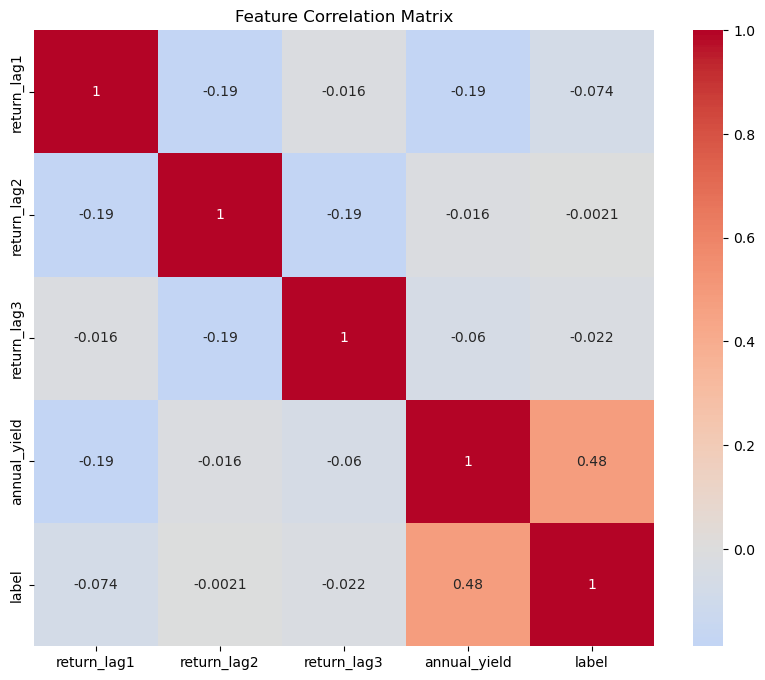

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)

plt.title('Feature Correlation Matrix')
plt.show()

In [20]:
df.corr()

,return_lag1,return_lag2,return_lag3,annual_yield,label
return_lag1,1.000000,-0.187028,-0.016212,-0.187061,-0.074178
return_lag2,-0.187028,1.000000,-0.187139,-0.016180,-0.002064
return_lag3,-0.016212,-0.187139,1.000000,-0.059535,-0.022454
annual_yield,-0.187061,-0.016180,-0.059535,1.000000,0.482234
label,-0.074178,-0.002064,-0.022454,0.482234,1.000000


In [21]:
asset_name = "Egyptian Treasury Bills (Fixed Income)" 
sns.set_theme(style="darkgrid", palette="muted")

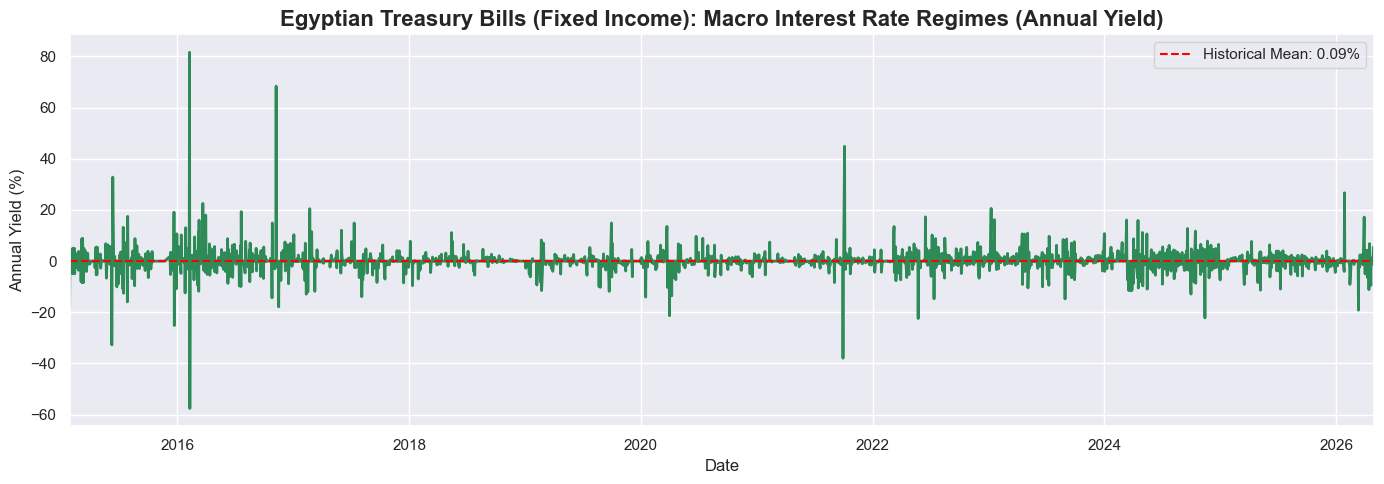

In [22]:
# ========================================================
# PLOT 1 - Macro Trend (Annual Yield)
# ========================================================
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['annual_yield'], color='seagreen', linewidth=2)
plt.fill_between(df.index, df['annual_yield'], color='seagreen', alpha=0.2)

plt.title(f"{asset_name}: Macro Interest Rate Regimes (Annual Yield)", fontsize=16, fontweight='bold')
plt.ylabel("Annual Yield (%)")
plt.xlabel("Date")

# Add a horizontal line for the historical average
mean_yield = df['annual_yield'].mean()
plt.axhline(mean_yield, color='red', linestyle='--', label=f"Historical Mean: {mean_yield:.2f}%")

plt.legend()
plt.margins(x=0)
plt.tight_layout()
plt.show()

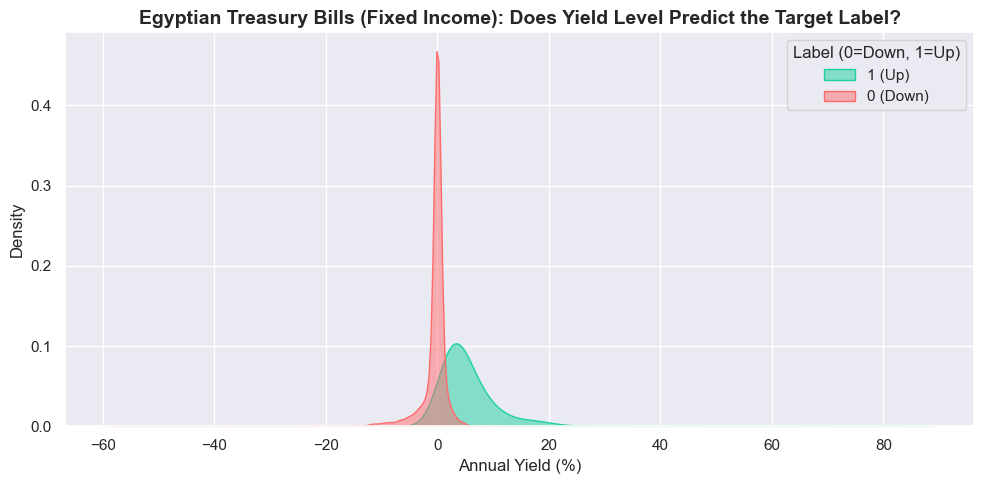

In [23]:
# ========================================================
# PLOT 2 - Yield Distribution by Target Label
# ========================================================
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='annual_yield', hue='label', fill=True, common_norm=False, palette=['#ff6b6b', '#1dd1a1'], alpha=0.5)

plt.title(f"{asset_name}: Does Yield Level Predict the Target Label?", fontsize=14, fontweight='bold')
plt.xlabel("Annual Yield (%)")
plt.ylabel("Density")
plt.legend(title='Label (0=Down, 1=Up)', labels=['1 (Up)', '0 (Down)'])

plt.tight_layout()
plt.show()

C:\Users\moata\AppData\Local\Temp\ipykernel_13396\90245359.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette=['#ff6b6b', '#1dd1a1'])


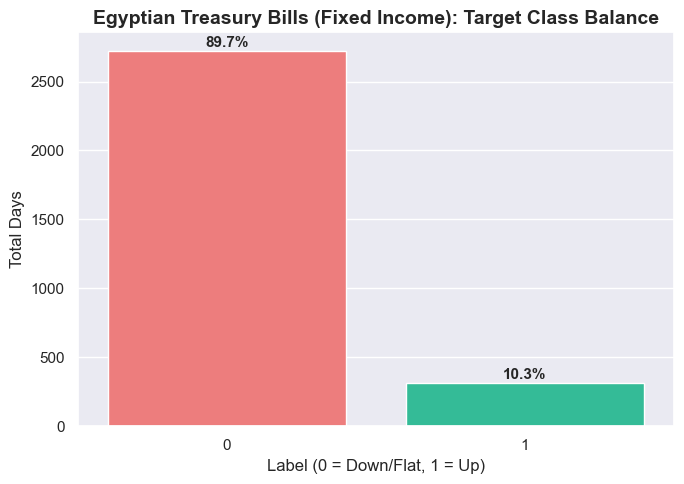

In [24]:
# ========================================================
# PLOT 3 - Target Class Balance
# ========================================================
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='label', palette=['#ff6b6b', '#1dd1a1'])
plt.title(f"{asset_name}: Target Class Balance", fontsize=14, fontweight='bold')
plt.xlabel("Label (0 = Down/Flat, 1 = Up)")
plt.ylabel("Total Days")

# Calculate and add percentages to the bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + (total * 0.01)
    ax.annotate(percentage, (x, y), ha='center', fontweight='bold', fontsize=11)
    
plt.tight_layout()
plt.show()

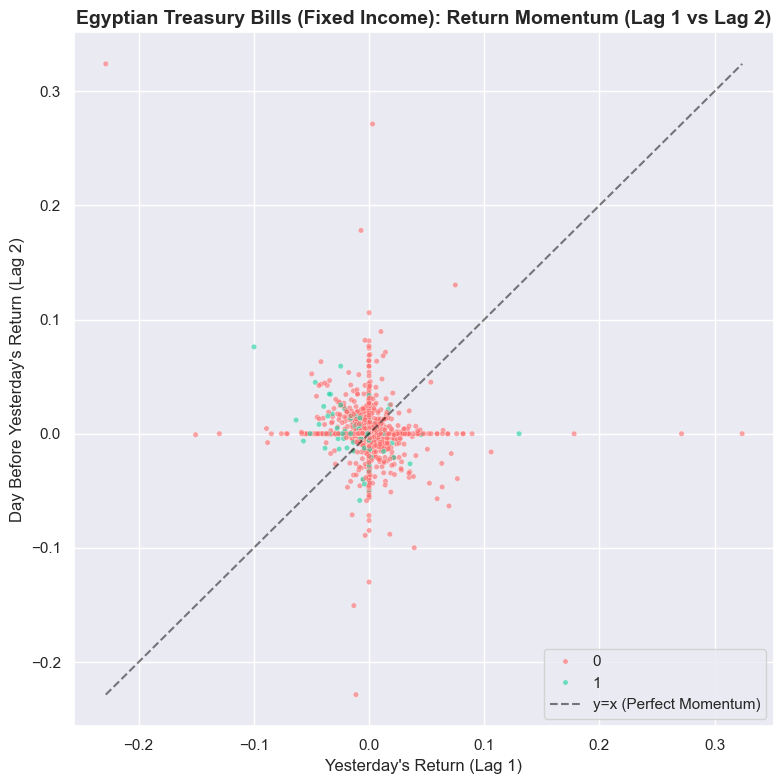

In [ ]:
# ========================================================
# PLOT 4 - Market Microstructure (Lag 1 vs Lag 2)
# ========================================================
plt.figure(figsize=(8, 8))
sns.scatterplot(data=df, x='return_lag1', y='return_lag2', hue='label', palette=['#ff6b6b', '#1dd1a1'], alpha=0.6, s=15)

# Add a dashed line representing y=x (perfect correlation)
limits = [min(df['return_lag1'].min(), df['return_lag2'].min()), 
          max(df['return_lag1'].max(), df['return_lag2'].max())]
plt.plot(limits, limits, color='black', linestyle='--', alpha=0.5, label='y=x (Perfect Momentum)')

plt.title(f"{asset_name}: Return Momentum (Lag 1 vs Lag 2)", fontsize=14, fontweight='bold')
plt.xlabel("Yesterday's Return (Lag 1)")
plt.ylabel("Day Before Yesterday's Return (Lag 2)")
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
df.to_csv('final_data/final_tbills.csv')